imports

In [ ]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display
import sys
import random
PROJECT_ROOT = Path.cwd().parents[2]

if str(PROJECT_ROOT) not in sys.path:
	sys.path.insert(0, str(PROJECT_ROOT))
from DetectionModel.constants.constants.detection_model import DetectionModelConstants

In [2]:
DATASET_DIR = DetectionModelConstants.PROJECT_ROOT/ "DetectionModel" / "datasets_monai"

PROBLEM_IMGS_DF_PATH=DATASET_DIR / "analysis" / "problematic_images.csv"

In [3]:
df=pd.read_csv(PROBLEM_IMGS_DF_PATH)
print(df.columns.to_list())

['filepath', 'filename', 'split', 'mean', 'std', 'min_val', 'max_val', 'dark_pixel_ratio', 'mid_pixel_ratio', 'bright_pixel_ratio', 'body_ratio', 'lung_body_ratio', 'lung_region_count', 'body_aspect_ratio', 'content_width_ratio', 'content_height_ratio', 'content_coverage', 'is_uniform', 'is_too_dark', 'is_too_bright', 'is_missing_contrast', 'has_no_dark_background', 'has_insufficient_lung', 'has_insufficient_tissue', 'has_bad_aspect_ratio', 'has_low_content_coverage', 'is_problematic', 'problem_type', 'patient_id', 'nodule_idx', 'slice_idx']


In [4]:
DF_FILTER= df["problem_type"] == "BAD_GEOMETRY"

bad_geo_df = df[DF_FILTER]
print(bad_geo_df.shape)

(1182, 31)


In [5]:
def load_rand_image(imgs_path_col):
    RAND_IMG_PATH = imgs_path_col.sample(n=1).iloc[0]
    RAND_IMG_PATH = str((PROJECT_ROOT / RAND_IMG_PATH).resolve())
    return Image(filename=RAND_IMG_PATH)


import matplotlib.pyplot as plt
import math
import cv2  # Assuming you are using cv2 for loading
import numpy as np

def show_images(images, rows=1, titles=None, figsize=(15, 5), cmap='gray'):
    """
    Display a list of images in a grid.
    
    Args:
        images: List of numpy arrays (images).
        rows: Number of rows desired.
        titles: Optional list of strings for image titles.
        figsize: Tuple (width, height) for the whole figure.
        cmap: Colormap (default 'gray' for CT scans).
    """
    n = len(images)
    if n == 0:
        print("No images to display.")
        return

    # Calculate columns based on n and rows
    cols = math.ceil(n / rows)

    # Create subplots
    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    # Flatten axes for easy iteration (handle case of single image vs multiple)
    axes = np.array([axes]) if n == 1 else axes.flatten()
    for i, ax in enumerate(axes):
        if i < n:
            # Display image
            ax.imshow(images[i], cmap=cmap)

            # Add title if provided
            if titles and i < len(titles):
                ax.set_title(titles[i], fontsize=10)

        ax.axis('off')
    plt.tight_layout()
    plt.show()

def load_cv_image(img_path):
    return cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

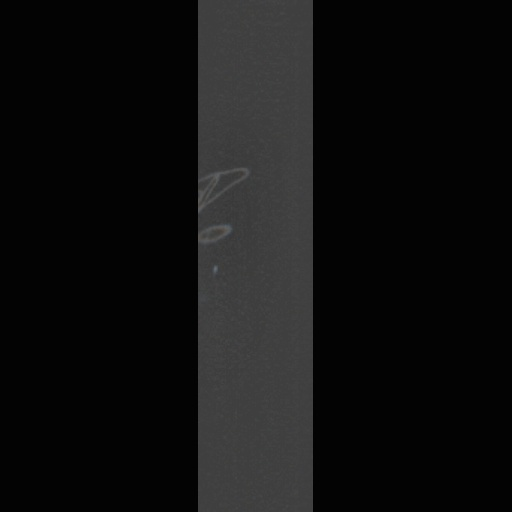

In [6]:
IMAGES_PATH_COL=bad_geo_df["filepath"]


img=load_rand_image(IMAGES_PATH_COL)

display(img)

In [7]:





sample_df = bad_geo_df.sample(n=min(10, len(bad_geo_df)))
    
loaded_images = []
titles = []

for _, row in sample_df.iterrows():
        img_path = row['filepath']
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is not None:
            loaded_images.append(img)
            # Title with filename and Aspect Ratio for context
            titles.append(f"{row['filename']}\nAR: {row.get('body_aspect_ratio', '?')}")

    # 4. Use the function
print(f"Showing {len(loaded_images)} samples marked as BAD_GEOMETRY...")
show_images(loaded_images, rows=2, titles=titles, figsize=(20, 8))


Showing 0 samples marked as BAD_GEOMETRY...
No images to display.


problem: INSUFFICIENT_LUNG



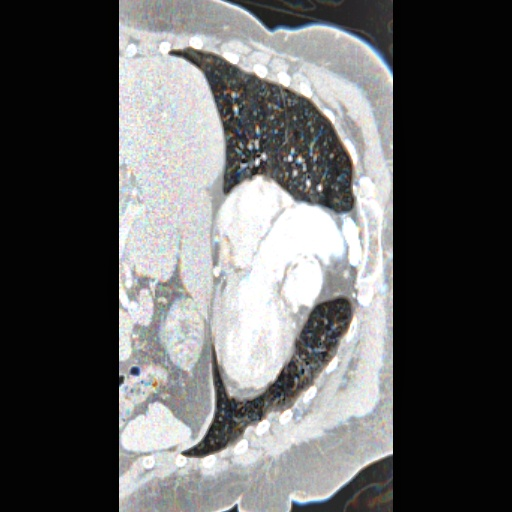

In [8]:
problem_types=df["problem_type"].unique()

RAND_PROBLEM=random.choice(list(problem_types))

PROBLEM_FILTER=(df["problem_type"]==RAND_PROBLEM)

RAND_PROBLEM_IMAGES_PATHS=df[PROBLEM_FILTER]["filepath"]


rand_img = load_rand_image(RAND_PROBLEM_IMAGES_PATHS)

print(f"problem: {RAND_PROBLEM}\n")
display(rand_img)
